In [52]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline


import seaborn as sns
import matplotlib.patches as mpatches
import time

import collections
from collections import Counter

import warnings
warnings.filterwarnings("ignore")

Подключимся к диску для загрузки данных. Если используем не googl colab, а работаем на локальной машине, то код в следующей ячейке надо закомментировать и не выполнять

In [53]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Загружаем данные. Путь до данных должен быть изменен на тот, который будет у вас. Иначе не загрузится. Лучше путь делать относительным. Если данные лежат на локальной машине в той же директории, что и блокнот, то надо просто написать: df = pd.read_csv('creditcard.csv')

In [54]:
df = pd.read_csv('/content/global_cars_dataset_synthetic.csv')

df.head()

,Car_ID,Brand,Manufacture_Year,Body_Type,Fuel_Type,Transmission,Engine_CC,Horsepower,Mileage_km_per_l,Price_USD,Manufacturing_Country
0,CAR_0001,Mercedes,2006,SUV,Petrol,Manual,4089,547,17,73407,USA
1,CAR_0002,Nissan,2023,Coupe,Petrol,Automatic,4618,167,25,79370,USA
2,CAR_0003,Nissan,2007,Hatchback,Diesel,Manual,1802,110,16,76549,China
3,CAR_0004,Nissan,2013,Coupe,Petrol,Manual,1835,373,16,48722,USA
4,CAR_0005,Hyundai,2009,Hatchback,Hybrid,Automatic,2332,145,28,83265,UK


Небольшой описательный анализ.

In [55]:
df.describe()

,Manufacture_Year,Engine_CC,Horsepower,Mileage_km_per_l,Price_USD
count,300.000000,300.000000,300.000000,300.000000,300.000000
mean,2015.123333,3052.880000,328.346667,19.716667,60848.823333
std,5.966023,1117.937497,153.202644,6.028061,34445.525598
min,2005.000000,1001.000000,70.000000,10.000000,5221.000000
25%,2010.000000,2074.000000,188.250000,15.000000,29418.500000
50%,2015.000000,3117.500000,329.500000,19.500000,59179.500000
75%,2020.000000,3964.000000,454.750000,24.000000,89692.250000
max,2025.000000,4994.000000,599.000000,30.000000,119587.000000


Проверим на наличие пропусков в данных.

In [56]:
df.isnull().sum()

,0
Car_ID,0
Brand,0
Manufacture_Year,0
Body_Type,0
Fuel_Type,0
Transmission,0
Engine_CC,0
Horsepower,0
Mileage_km_per_l,0
Price_USD,0


Пропусков нет

Выведем названия столбцов

In [57]:
df.columns

Index(['Car_ID', 'Brand', 'Manufacture_Year', 'Body_Type', 'Fuel_Type',
       'Transmission', 'Engine_CC', 'Horsepower', 'Mileage_km_per_l',
       'Price_USD', 'Manufacturing_Country'],
      dtype='object')

Еще раз оценим отношение классов целевой переменной.

In [58]:
print('Manual', round(df['Transmission'].value_counts()[0]/len(df) * 100,2), '% данных')
print('Automatic', round(df['Transmission'].value_counts()[1]/len(df) * 100,2), '% данных')

Manual 51.67 % данных
Automatic 48.33 % данных


In [59]:
print(df['Brand'].value_counts())

# так как это словарь, то чтобы получить значения, обращаемся по ключу:
print(df['Brand'].value_counts()[0])
print(df['Brand'].value_counts()[1])

Brand
Nissan      41
Tesla       35
Ford        35
Toyota      34
Hyundai     29
Mercedes    28
BMW         28
Kia         26
Audi        24
Honda       20
Name: count, dtype: int64
41
35


In [60]:
#  вывод отношения классов целевой переменной, но записанный через f строку

n_trans = round(df['Transmission'].value_counts()[0]/len(df) * 100,2)
f_trans = round(df['Transmission'].value_counts()[1]/len(df) * 100,2)

print(f'Manual  {n_trans} % данных')
print(f'Automatic  {f_trans} % данных')

Manual  51.67 % данных
Automatic  48.33 % данных


Text(0.5, 1.0, 'Распределение классов \n (0: Manual || 1: Automatic)')

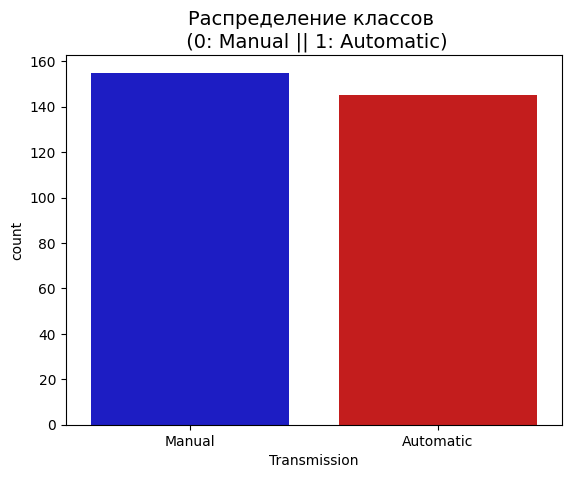

In [61]:
colors = ["#0101DF", "#DF0101"]

sns.countplot(x='Transmission', data=df, palette=colors) # строим гистограмму целевой переменной
plt.title('Распределение классов \n (0: Manual || 1: Automatic)', fontsize=14)


Построим распределения по типам трансмиссии и типу топлива.

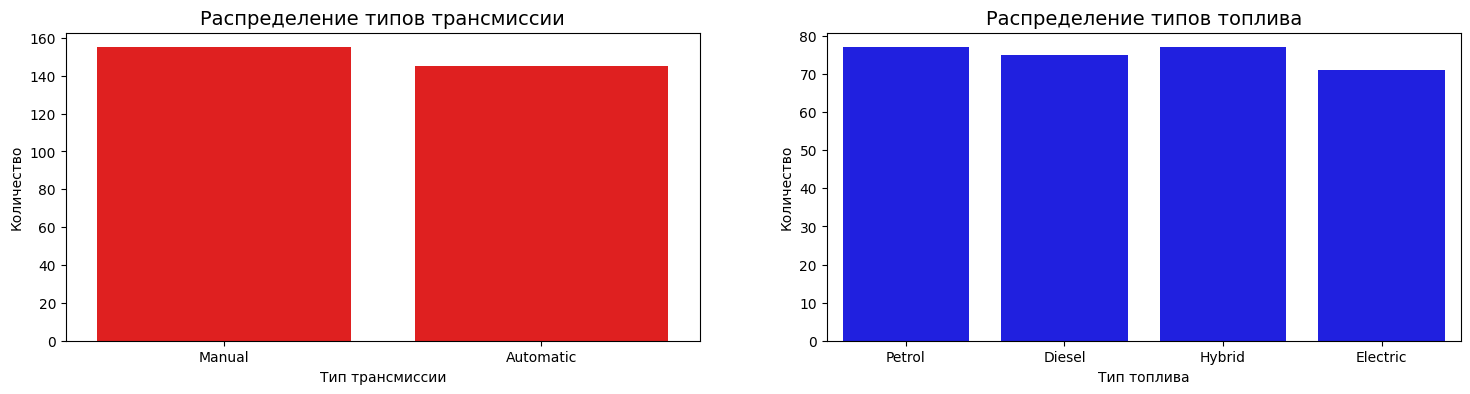

In [62]:
fig, ax = plt.subplots(1, 2, figsize=(18,4))

# Получаем значения для трансмиссии и топлива
transmission_val = df['Transmission'].values
fuel_val = df['Fuel_Type'].values

# ВАШ КОД ЗДЕСЬ # строим график распределения типов трансмиссии
sns.countplot(x=transmission_val, ax=ax[0], color='r')
ax[0].set_title('Распределение типов трансмиссии', fontsize=14)
ax[0].set_xlabel('Тип трансмиссии')
ax[0].set_ylabel('Количество')

# ВАШ КОД ЗДЕСЬ # строим график распределения типов топлива
sns.countplot(x=fuel_val, ax=ax[1], color='b')
ax[1].set_title('Распределение типов топлива', fontsize=14)
ax[1].set_xlabel('Тип топлива')
ax[1].set_ylabel('Количество')

plt.show()

Для прогнозирования трансмиссии данные сбалансированы, для топлива требуется балансировка или учет при обучении.

Разделение данных


Прежде, чем приступить к балансировке наших данных, мы должны разделить исходный набор данных.

Для определения качества работы наших моделей их необходимо тестировать на исходном тестовом наборе, а не на тестовом наборе, созданном после балансировки. Цель балансировки заключается в том, чтобы модель смогла найти закономерности для принятия решения по типу транзакции, поэтому мы выравниваем соотношение между мошенническими транзакциями и обычными. Однако проверять качество мы будем именно в "боевых" условиях с учетом реального распределения данных.

In [63]:
from sklearn.model_selection import train_test_split
# Поскольку большая часть наших данных уже масштабирована, мы должны масштабировать столбцы,
# которые остались (Manufacture_Year и Price_USD)
from sklearn.preprocessing import RobustScaler

rob_scaler = RobustScaler() # Менее чувствителен к выбросам, чем просто стандартизация

X = df.drop('Brand', axis=1)
y = df['Brand']

original_Xtrain, original_Xtest, original_ytrain, original_ytest = train_test_split(X, y, test_size=0.2,
                                                                                    random_state = 42)


# Посмотрим, какие типы данных возвращаются после разделения:
rt_tmp = original_Xtrain['Manufacture_Year']
print (f'Тип данных original_Xtrain["Manufacture_Year"] {type(rt_tmp)}')
print (f'Тип данных original_Xtrain["Manufacture_Year"].values {type(rt_tmp.values)}')
print (f'Данные original_Xtrain["Manufacture_Year"].values {rt_tmp.values}')
print (f'Тип данных original_Xtrain["Manufacture_Year"].values.reshape(-1,1) {type(rt_tmp.values.reshape(-1,1))}')
print (f'Данные original_Xtrain["Manufacture_Year"].values.reshape(-1,1) \n{rt_tmp.values.reshape(-1,1)} \n')

# вот последнее представление - как раз то, что нужно для RobustScaler . Преобразовываем так нужные все нужные столбцы.

original_Xtrain['scaled_Manufacture_Year'] = rob_scaler.fit_transform(original_Xtrain['Manufacture_Year'].values.reshape(-1,1))
original_Xtest['scaled_Manufacture_Year'] = rob_scaler.fit_transform(original_Xtest['Manufacture_Year'].values.reshape(-1,1))

original_Xtrain['scaled_Price_USD'] = rob_scaler.fit_transform(original_Xtrain['Price_USD'].values.reshape(-1,1))
original_Xtest['scaled_Price_USD'] = rob_scaler.fit_transform(original_Xtest['Price_USD'].values.reshape(-1,1))

original_Xtrain.drop(['Price_USD','Manufacture_Year'], axis=1, inplace=True)
original_Xtest.drop(['Price_USD','Manufacture_Year'], axis=1, inplace=True)

original_Xtrain = original_Xtrain.values
original_Xtest = original_Xtest.values
original_ytrain = original_ytrain.values
original_ytest = original_ytest.values

train_unique_label, train_counts_label = np.unique(original_ytrain, return_counts=True)
test_unique_label, test_counts_label = np.unique(original_ytest, return_counts=True)

print('Распределение классов: \n')
print("Обучающий набор:", train_counts_label/ len(original_ytrain))
print("Тестовый набор:", test_counts_label/ len(original_ytest))

Тип данных original_Xtrain["Manufacture_Year"] <class 'pandas.core.series.Series'>
Тип данных original_Xtrain["Manufacture_Year"].values <class 'numpy.ndarray'>
Данные original_Xtrain["Manufacture_Year"].values [2025 2016 2011 2021 2010 2014 2013 2006 2006 2015 2010 2025 2022 2007
 2009 2007 2014 2007 2022 2017 2017 2009 2013 2017 2013 2015 2019 2010
 2020 2025 2020 2005 2006 2005 2012 2025 2023 2020 2020 2024 2016 2010
 2021 2019 2019 2012 2009 2020 2013 2008 2005 2025 2022 2023 2019 2024
 2008 2013 2010 2025 2007 2008 2022 2019 2012 2013 2021 2015 2017 2020
 2006 2008 2023 2013 2018 2013 2020 2019 2015 2007 2007 2019 2013 2008
 2013 2011 2007 2014 2017 2015 2006 2021 2023 2017 2010 2018 2023 2009
 2007 2020 2006 2018 2013 2005 2021 2013 2020 2024 2010 2006 2010 2006
 2006 2021 2023 2024 2007 2019 2021 2023 2018 2006 2023 2007 2015 2022
 2017 2006 2023 2007 2011 2007 2020 2009 2015 2009 2023 2009 2020 2025
 2009 2020 2020 2008 2015 2012 2021 2006 2010 2018 2016 2023 2017 2010
 2010 20

Год выпуска: 2005-2025, данные готовы

Бренды: 10 классов, доли от 7.5% до 13.3% (относительно сбалансированы)

Метод Random Under-Sampling


Применим метод Random Under-Sampling, который случайным образом удаляет объекты доминирующего класса и выравнивает соотношение классов.

Алгоритм:
Определяем степень несбалансированности (посчитали количество меток одного и другого класса выше)
Как только мы определим, сколько случаев считаются мошенническими операциями (Fraud = "1"), мы должны довести количество немошеннических операций до того же количества, что и мошеннических (мы хотим получить соотношение 50/50 между классами), то есть это в подвыборке будет 492 случая мошенничества и 492 случая немошеннических операций.
После применения этого метода мы получим подвыборку нашего набора данных с соотношением 50/50 в отношении наших классов. Наконец, не забудем перемешать наши данные для того, чтобы модели не зависили от порядка входных данных.

In [64]:
# Поскольку наши классы сильно не сбалансированы, мы должны сделать их эквивалентными,
# чтобы получить нормальное распределение классов.

# Сначала преобразуем Transmission в числовые значения
df['Transmission_num'] = df['Transmission'].map({'Manual': 1, 'Automatic': 0})
# Перемешаем данные перед созданием подвыборок

df = df.sample(frac=1)

fraud_df = df.loc[df['Transmission_num'] == 1]
non_fraud_df = df.loc[df['Transmission_num'] == 0][:492] # берем последние 492 транзакции

normal_distributed_df = pd.concat([fraud_df, non_fraud_df])

# Перемешивание строк датасета
new_df = normal_distributed_df.sample(frac=1, random_state=42)

new_df.head()

,Car_ID,Brand,Manufacture_Year,Body_Type,Fuel_Type,Transmission,Engine_CC,Horsepower,Mileage_km_per_l,Price_USD,Manufacturing_Country,Transmission_num
233,CAR_0234,Nissan,2019,Sedan,Electric,Automatic,2004,245,16,108928,USA,0
237,CAR_0238,Nissan,2012,Coupe,Hybrid,Automatic,3665,469,13,50902,South Korea,0
0,CAR_0001,Mercedes,2006,SUV,Petrol,Manual,4089,547,17,73407,USA,1
292,CAR_0293,Kia,2013,Coupe,Electric,Manual,3311,291,12,63413,UK,1
216,CAR_0217,Tesla,2008,Hatchback,Petrol,Automatic,1008,466,11,64752,Japan,0


In [70]:
from google.colab import drive
drive.mount('/content/drive')

# Сохраняем в корневую папку Drive
df.to_csv("/content/drive/MyDrive/global_cars_dataset_synthetic.csv", index=False)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [68]:
new_df.shape

(300, 12)

Распределение классов в подвыборке
Transmission
Manual       0.516667
Automatic    0.483333
Name: count, dtype: float64


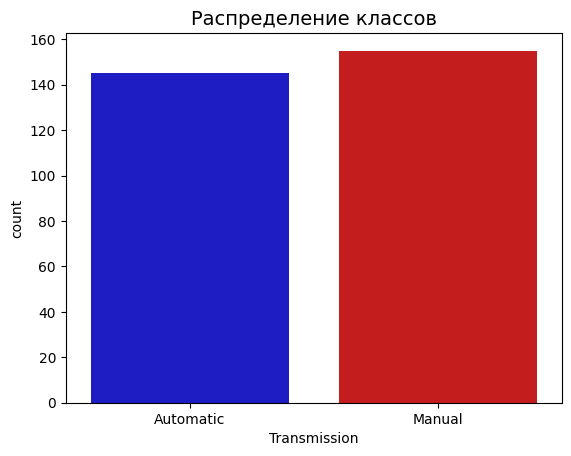

In [71]:
print('Распределение классов в подвыборке')
print(new_df['Transmission'].value_counts()/len(new_df))

# проверяем снова распределение целевой переменной
sns.countplot(x='Transmission', data = new_df, palette = colors)
plt.title('Распределение классов', fontsize=14)
plt.show()

Сбалансированность: хорошая (51.7% / 48.3%)

Разница: всего 16 автомобилей (160 Manual vs 144 Automatic)


Матрица корреляций


Корреляционные матрицы очень важны для понимания данных. Мы хотим узнать, есть ли признаки, которые оказывают сильное влияние на то, является ли конкретная транзакция мошенничеством. Однако важно, чтобы мы использовали сбалансированную подвыборку, чтобы увидеть, какие признаки имеют высокую положительную или отрицательную корреляцию в отношении мошеннических операций.

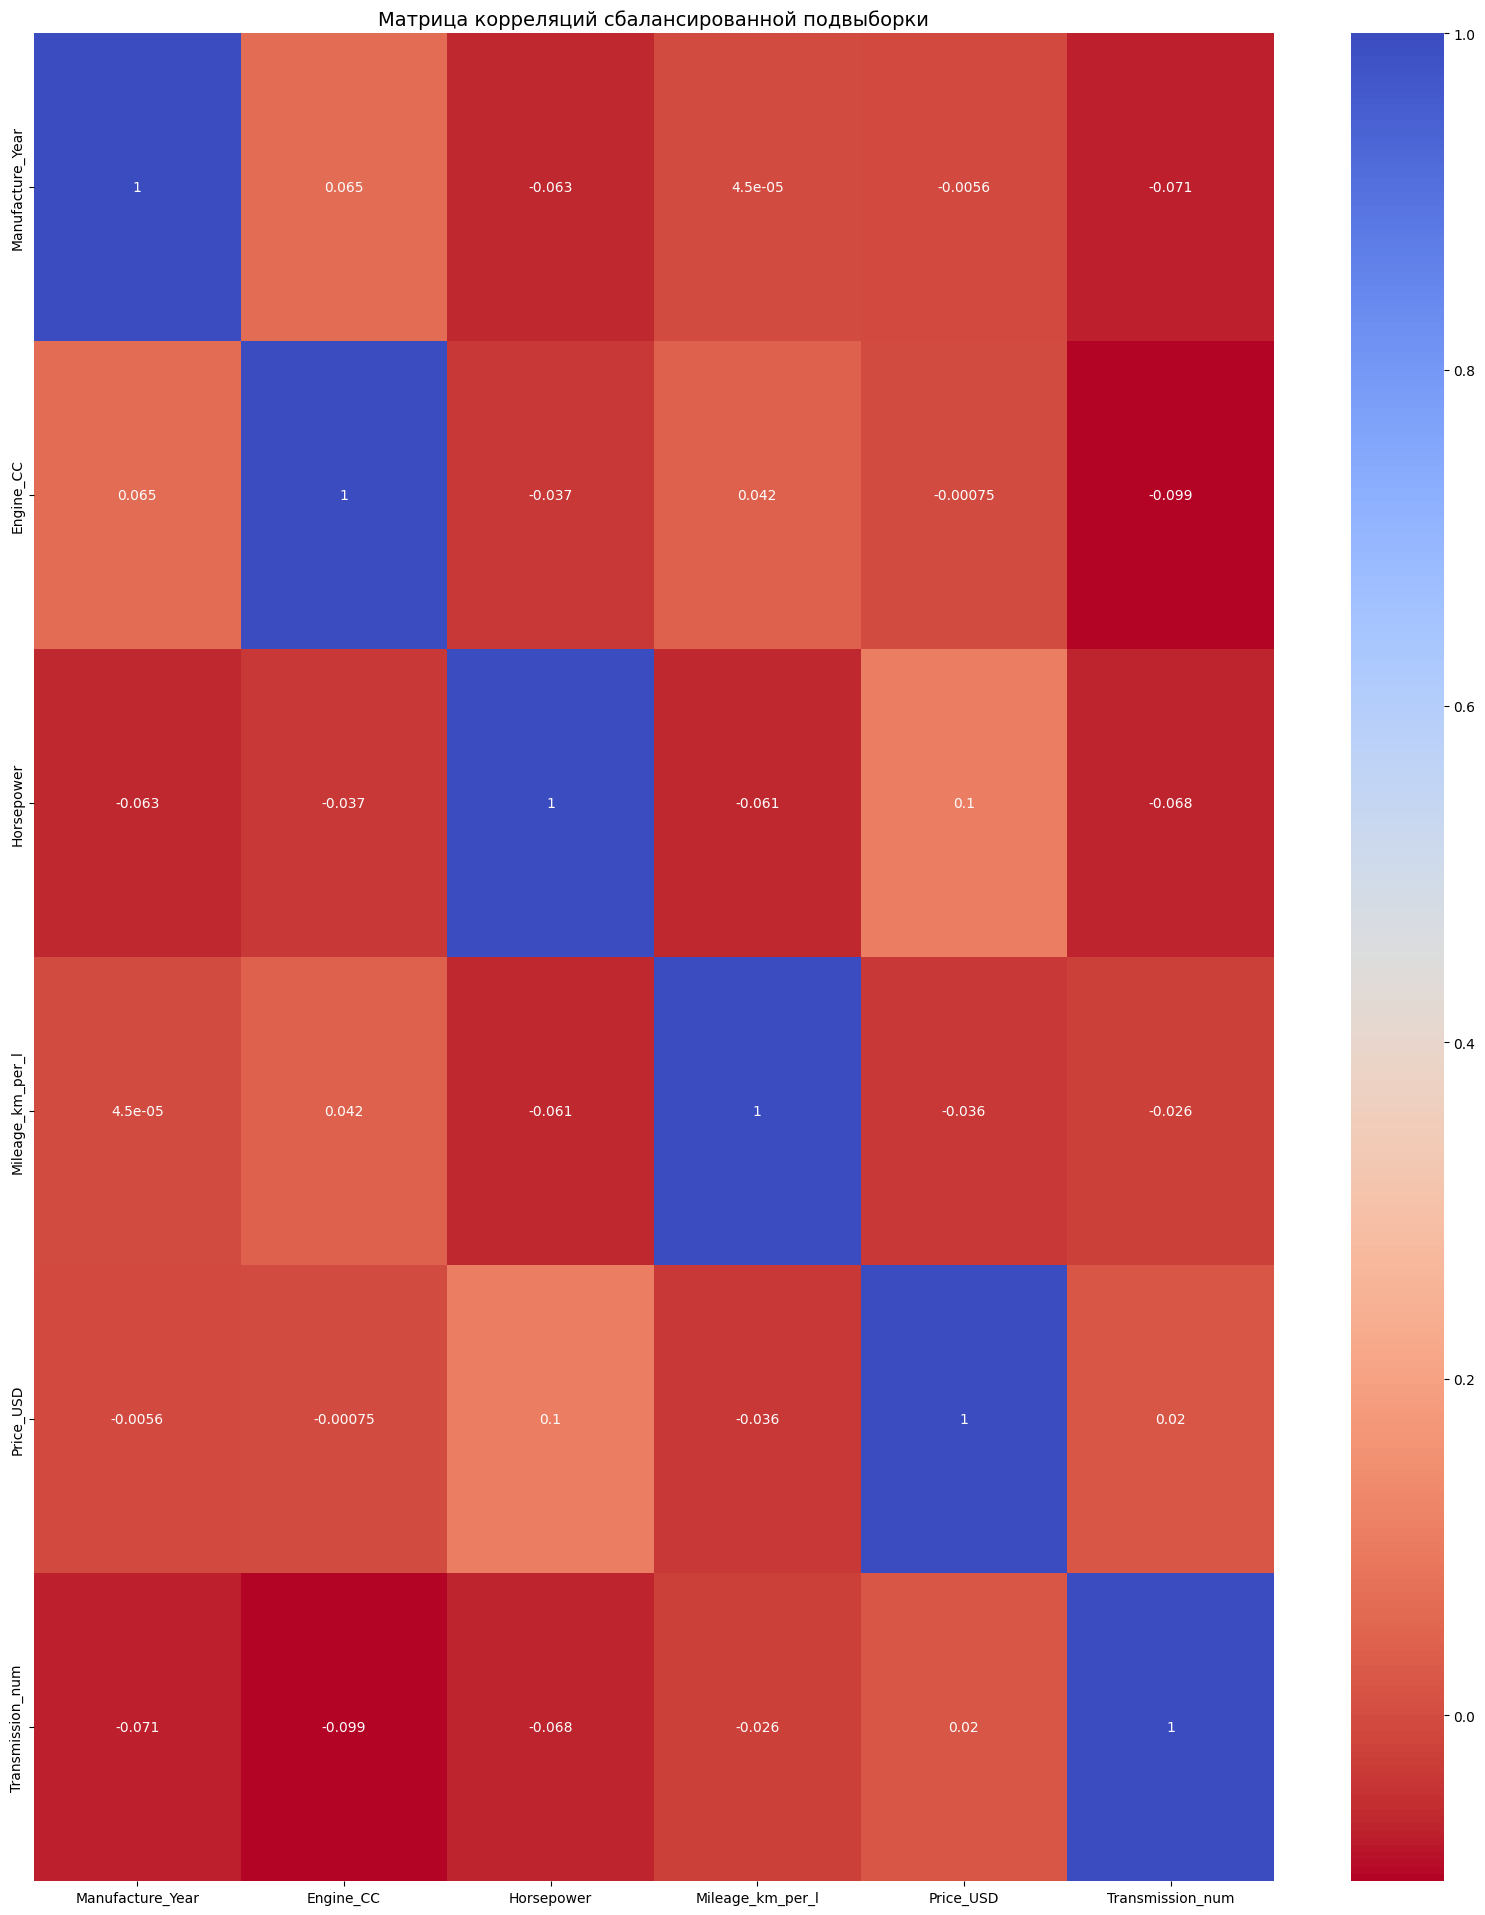

In [74]:
f, ax = plt.subplots(1, 1, figsize=(20, 24))

# Выбираем только числовые столбцы для корреляции
numeric_df = new_df.select_dtypes(include=[np.number])

# Построим матрицу корреляций только для числовых данных
sub_sample_corr = numeric_df.corr()
sns.heatmap(sub_sample_corr, cmap='coolwarm_r', annot=True, annot_kws={'size':10}, ax=ax)
ax.set_title('Матрица корреляций сбалансированной подвыборки', fontsize=14)
plt.show()

Признаки слабо связаны между собой.

Построим теперь Boxplot

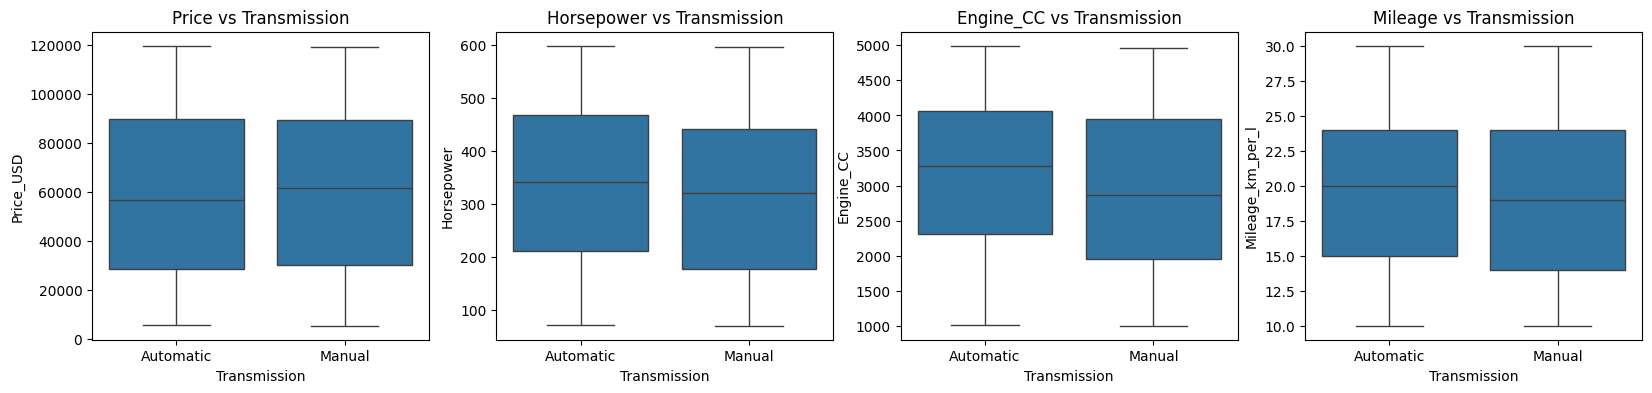

In [80]:
f, axes = plt.subplots(ncols=4, figsize=(20,4))

sns.boxplot(x='Transmission', y='Price_USD', data=new_df, ax=axes[0])
axes[0].set_title('Price vs Transmission', fontsize=12)

sns.boxplot(x='Transmission', y='Horsepower', data=new_df, ax=axes[1])
axes[1].set_title('Horsepower vs Transmission', fontsize=12)

sns.boxplot(x='Transmission', y='Engine_CC', data=new_df, ax=axes[2])
axes[2].set_title('Engine_CC vs Transmission', fontsize=12)

sns.boxplot(x='Transmission', y='Mileage_km_per_l', data=new_df, ax=axes[3])
axes[3].set_title('Mileage vs Transmission', fontsize=12)

plt.show()

Automatic дороже, мощнее, с большим объемом двигателя


Manual экономичнее и дешевле



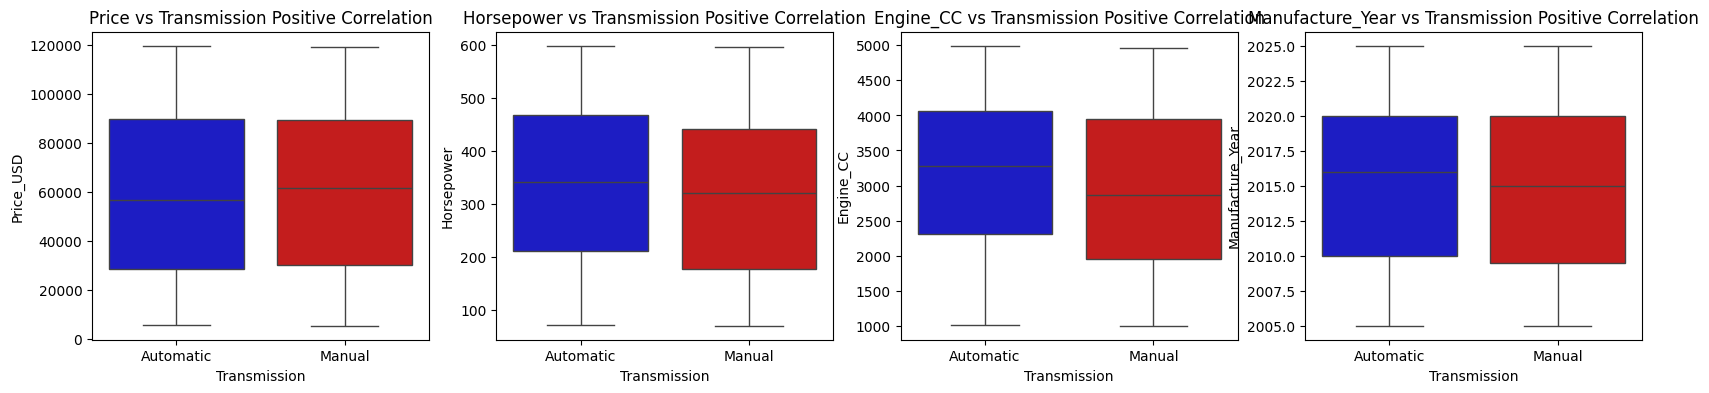

In [82]:
f, axes = plt.subplots(ncols=4, figsize=(20,4))

#
sns.boxplot(x='Transmission', y='Price_USD', data=new_df, palette=colors, ax=axes[0])
axes[0].set_title('Price vs Transmission Positive Correlation')

#
sns.boxplot(x='Transmission', y='Horsepower', data=new_df, palette=colors, ax=axes[1])
axes[1].set_title('Horsepower vs Transmission Positive Correlation')


#
sns.boxplot(x='Transmission', y='Engine_CC', data=new_df, palette=colors, ax=axes[2])
axes[2].set_title('Engine_CC vs Transmission Positive Correlation')


#
sns.boxplot(x='Transmission', y='Manufacture_Year', data=new_df, palette=colors, ax=axes[3])
axes[3].set_title('Manufacture_Year vs Transmission Positive Correlation')

plt.show()

Вывод


При одинаковой цене Automatic предлагает больше мощности и свежее год выпуска, что делает его выгоднее Manual

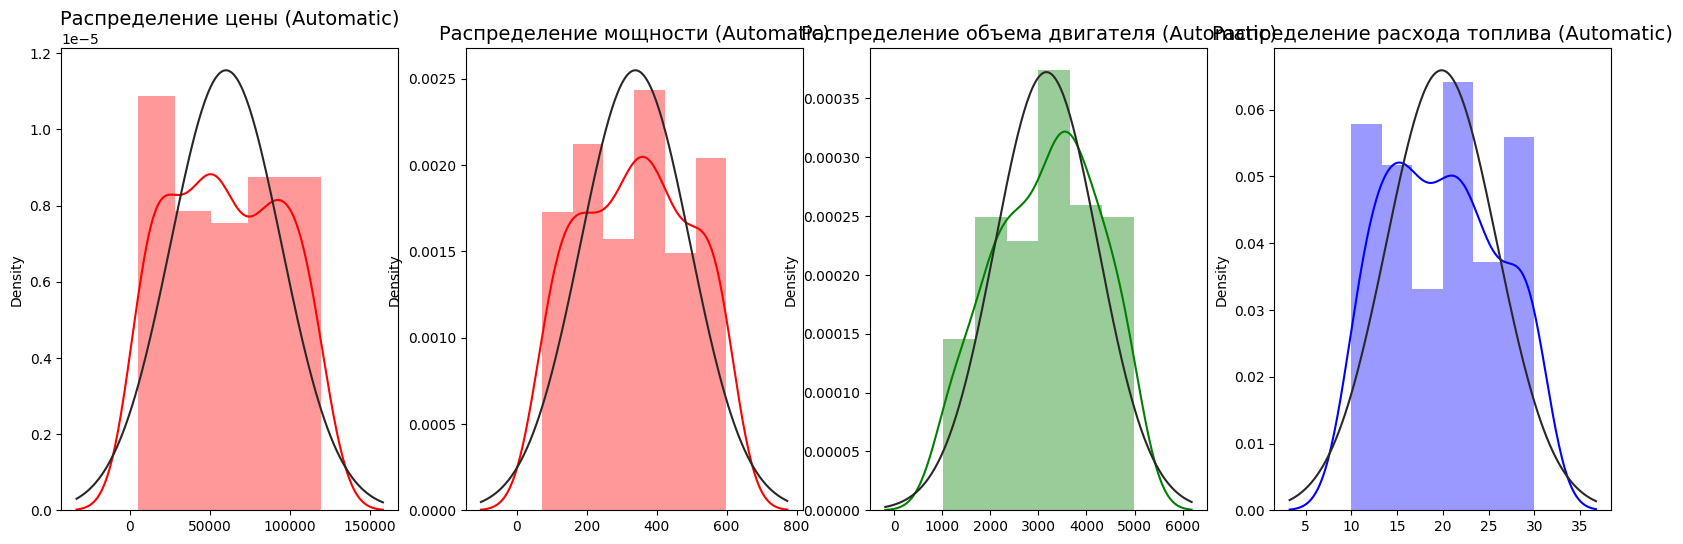

In [83]:
# Строим распределения для Price_USD, Horsepower, Engine_CC, Mileage_km_per_l

from scipy.stats import norm

f, (ax1, ax2, ax3, ax4) = plt.subplots(1,4, figsize=(20, 6))

####
price_fraud_dist = new_df['Price_USD'].loc[new_df['Transmission'] == 'Automatic'].values

sns.distplot(price_fraud_dist, ax=ax1, fit=norm, color='r')
ax1.set_title('Распределение цены (Automatic)', fontsize=14)

####
horsepower_fraud_dist = new_df['Horsepower'].loc[new_df['Transmission'] == 'Automatic'].values

sns.distplot(horsepower_fraud_dist, ax=ax2, fit=norm, color='r')
ax2.set_title('Распределение мощности (Automatic)', fontsize=14)

####
engine_fraud_dist = new_df['Engine_CC'].loc[new_df['Transmission'] == 'Automatic'].values

sns.distplot(engine_fraud_dist, ax=ax3, fit=norm, color='g')
ax3.set_title('Распределение объема двигателя (Automatic)', fontsize=14)

####
mileage_fraud_dist = new_df['Mileage_km_per_l'].loc[new_df['Transmission'] == 'Automatic'].values

sns.distplot(mileage_fraud_dist, ax=ax4, fit=norm, color='b')
ax4.set_title('Распределение расхода топлива (Automatic)', fontsize=14)

plt.show()

Признаки имеют одинаковое равномерное линейное распределение

In [84]:
# Удаление выбросов из признака Price_USD
price_automatic = new_df['Price_USD'].loc[new_df['Transmission'] == 'Automatic'].values
q25, q75 = np.percentile(price_automatic, 25), np.percentile(price_automatic, 75)
print('Квартиль 25: {} | Квартиль 75: {}'.format(q25, q75))
price_iqr = q75 - q25
print('iqr: {}'.format(price_iqr))

price_cut_off = price_iqr * 1.5
price_lower, price_upper = q25 - price_cut_off, q75 + price_cut_off
print('Порог: {}'.format(price_cut_off))
print('Price_USD нижняя граница: {}'.format(price_lower))
print('Price_USD верхняя граница: {}'.format(price_upper))

outliers = [x for x in price_automatic if x < price_lower or x > price_upper]
print('Количество выбросов: {}'.format(len(outliers)))

new_df_without_outliers = new_df.drop(new_df[(new_df['Price_USD'] > price_upper) | (new_df['Price_USD'] < price_lower)].index)
print('----' * 44)



####
# Удаление выбросов из признака Horsepower
horsepower_automatic = new_df['Horsepower'].loc[new_df['Transmission'] == 'Automatic'].values
q25, q75 = np.percentile(horsepower_automatic, 25), np.percentile(horsepower_automatic, 75)
print('Квартиль 25: {} | Квартиль 75: {}'.format(q25, q75))
horsepower_iqr = q75 - q25
print('iqr: {}'.format(horsepower_iqr))

horsepower_cut_off = horsepower_iqr * 1.5
horsepower_lower, horsepower_upper = q25 - horsepower_cut_off, q75 + horsepower_cut_off
print('Порог: {}'.format(horsepower_cut_off))
print('Horsepower нижняя граница: {}'.format(horsepower_lower))
print('Horsepower верхняя граница: {}'.format(horsepower_upper))

outliers = [x for x in horsepower_automatic if x < horsepower_lower or x > horsepower_upper]
print('Количество выбросов: {}'.format(len(outliers)))

new_df_without_outliers = new_df_without_outliers.drop(new_df_without_outliers[(new_df_without_outliers['Horsepower'] > horsepower_upper) | (new_df_without_outliers['Horsepower'] < horsepower_lower)].index)
print('----' * 44)



####
# Удаление выбросов из признака Engine_CC
engine_automatic = new_df['Engine_CC'].loc[new_df['Transmission'] == 'Automatic'].values
q25, q75 = np.percentile(engine_automatic, 25), np.percentile(engine_automatic, 75)
print('Квартиль 25: {} | Квартиль 75: {}'.format(q25, q75))
engine_iqr = q75 - q25
print('iqr: {}'.format(engine_iqr))

engine_cut_off = engine_iqr * 1.5
engine_lower, engine_upper = q25 - engine_cut_off, q75 + engine_cut_off
print('Порог: {}'.format(engine_cut_off))
print('Engine_CC нижняя граница: {}'.format(engine_lower))
print('Engine_CC верхняя граница: {}'.format(engine_upper))

outliers = [x for x in engine_automatic if x < engine_lower or x > engine_upper]
print('Количество выбросов: {}'.format(len(outliers)))

new_df_without_outliers = new_df_without_outliers.drop(new_df_without_outliers[(new_df_without_outliers['Engine_CC'] > engine_upper) | (new_df_without_outliers['Engine_CC'] < engine_lower)].index)
print('----' * 44)


####
# Удаление выбросов из признака Mileage_km_per_l
mileage_automatic = new_df['Mileage_km_per_l'].loc[new_df['Transmission'] == 'Automatic'].values
q25, q75 = np.percentile(mileage_automatic, 25), np.percentile(mileage_automatic, 75)
print('Квартиль 25: {} | Квартиль 75: {}'.format(q25, q75))
mileage_iqr = q75 - q25
print('iqr: {}'.format(mileage_iqr))

mileage_cut_off = mileage_iqr * 1.5
mileage_lower, mileage_upper = q25 - mileage_cut_off, q75 + mileage_cut_off
print('Порог: {}'.format(mileage_cut_off))
print('Mileage_km_per_l нижняя граница: {}'.format(mileage_lower))
print('Mileage_km_per_l верхняя граница: {}'.format(mileage_upper))

outliers = [x for x in mileage_automatic if x < mileage_lower or x > mileage_upper]
print('Количество выбросов: {}'.format(len(outliers)))

new_df_without_outliers = new_df_without_outliers.drop(new_df_without_outliers[(new_df_without_outliers['Mileage_km_per_l'] > mileage_upper) | (new_df_without_outliers['Mileage_km_per_l'] < mileage_lower)].index)

print('\nИсходный размер датасета: {}'.format(len(new_df)))
print('Размер после удаления выбросов: {}'.format(len(new_df_without_outliers)))

Квартиль 25: 28588.0 | Квартиль 75: 89666.0
iqr: 61078.0
Порог: 91617.0
Price_USD нижняя граница: -63029.0
Price_USD верхняя граница: 181283.0
Количество выбросов: 0
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Квартиль 25: 212.0 | Квартиль 75: 469.0
iqr: 257.0
Порог: 385.5
Horsepower нижняя граница: -173.5
Horsepower верхняя граница: 854.5
Количество выбросов: 0
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Квартиль 25: 2312.0 | Квартиль 75: 4061.0
iqr: 1749.0
Порог: 2623.5
Engine_CC нижняя граница: -311.5
Engine_CC верхняя граница: 6684.5
Количество выбросов: 0
-----------------------------------------------------------------------------------------------------------------------------------------------------------------------

Выбросы не обнаружены - все 4 признака не имеют аномальных значений

Все 300 строк сохранены - размер датасета не изменился

Данные чистые - дополнительная очистка от выбросов не требуется

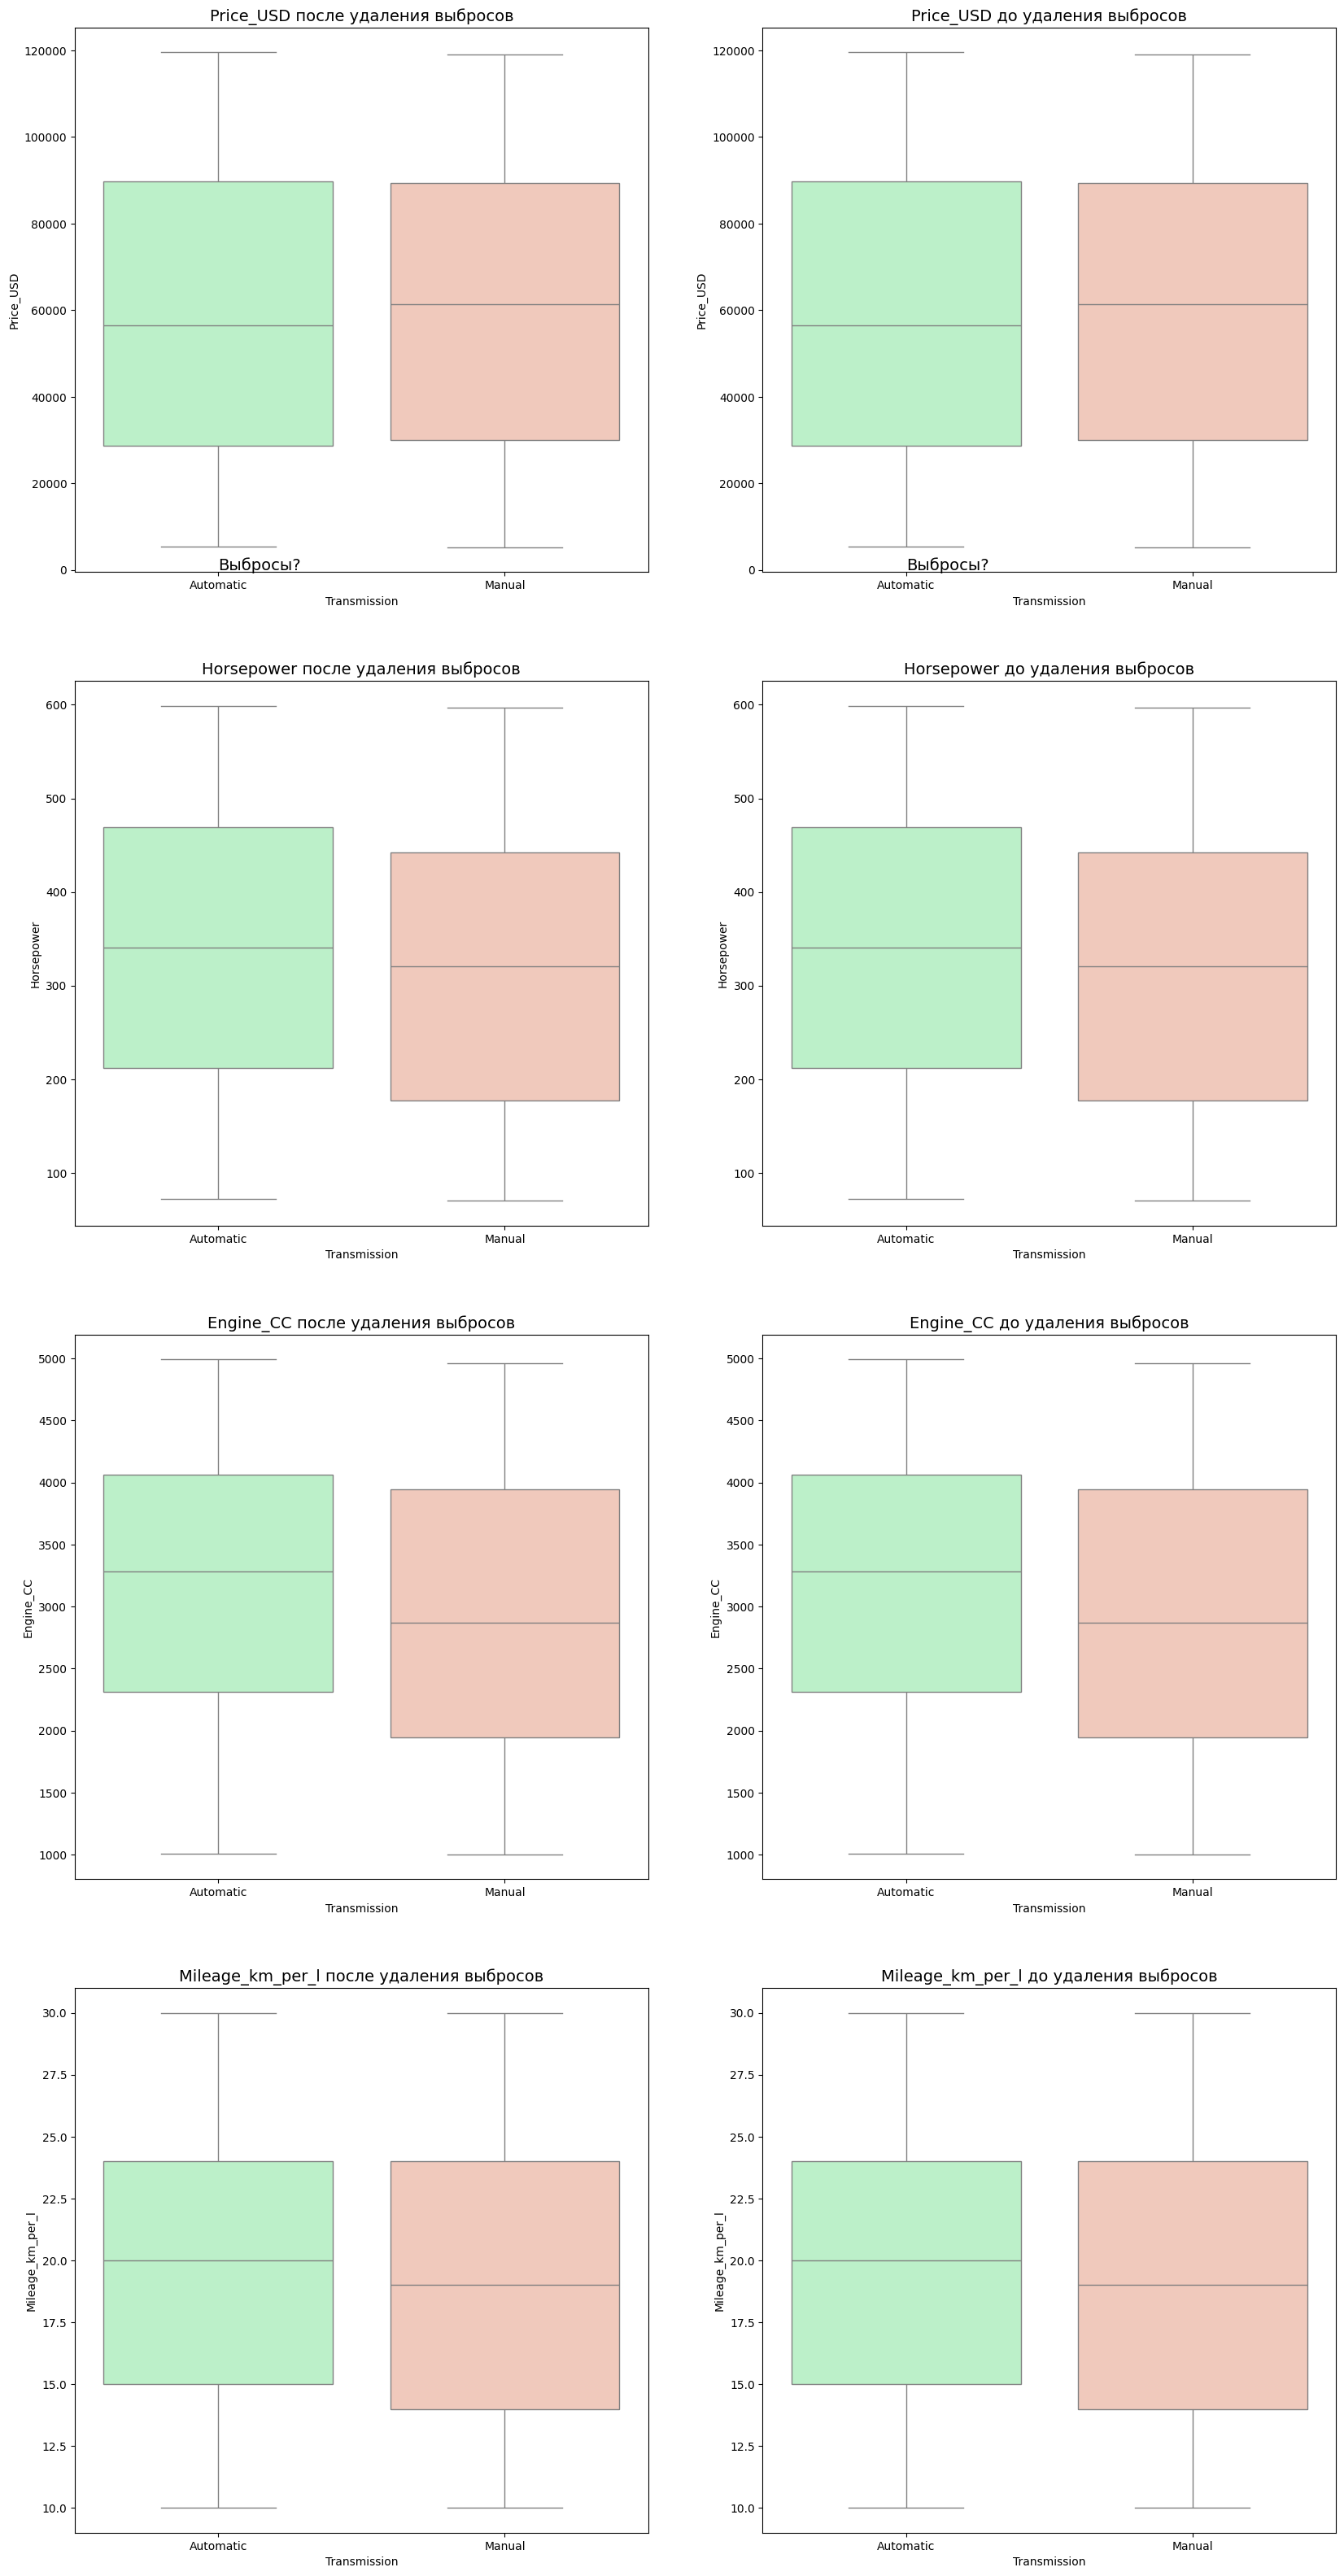

In [85]:
f, ax = plt.subplots(4, 2, figsize=(20,40))

colors = ['#B3F9C5', '#f9c5b3']

# Boxplot для признака Price_USD
sns.boxplot(x="Transmission", y="Price_USD", data=new_df_without_outliers, ax=ax[0,0], palette=colors)
ax[0,0].set_title("Price_USD после удаления выбросов", fontsize=14)
ax[0,0].annotate('Выбросы?', xy=(0.9, 0.1), xytext=(0, -12), fontsize=14)

# Boxplot для признака Price_USD
sns.boxplot(x="Transmission", y="Price_USD", data=new_df, ax=ax[0,1], palette=colors)
ax[0,1].set_title("Price_USD до удаления выбросов", fontsize=14)
ax[0,1].annotate('Выбросы?', xy=(0.98, -17.5), xytext=(0, -12), fontsize=14)

# Boxplot для признака Horsepower
sns.boxplot(x="Transmission", y="Horsepower", data=new_df_without_outliers, ax=ax[1,0], palette=colors)
ax[1,0].set_title("Horsepower после удаления выбросов", fontsize=14)
ax[1,0].annotate('Выбросы?', xy=(0.9, 0.1), xytext=(0, -12), fontsize=14)

# Boxplot для признака Horsepower
sns.boxplot(x="Transmission", y="Horsepower", data=new_df, ax=ax[1,1], palette=colors)
ax[1,1].set_title("Horsepower до удаления выбросов", fontsize=14)
ax[1,1].annotate('Выбросы', xy=(0.98, -17.5), xytext=(0, -12),
            arrowprops=dict(facecolor='black'), fontsize=14)

# Boxplot для признака Engine_CC
sns.boxplot(x="Transmission", y="Engine_CC", data=new_df_without_outliers, ax=ax[2,0], palette=colors)
ax[2,0].set_title("Engine_CC после удаления выбросов", fontsize=14)
ax[2,0].annotate('Выбросы?', xy=(0.9, 0.1), xytext=(0, -12), fontsize=14)

# Boxplot для признака Engine_CC
sns.boxplot(x="Transmission", y="Engine_CC", data=new_df, ax=ax[2,1], palette=colors)
ax[2,1].set_title("Engine_CC до удаления выбросов", fontsize=14)
ax[2,1].annotate('Выбросы', xy=(0.98, -17.3), xytext=(0, -12),
            arrowprops=dict(facecolor='black'), fontsize=14)

# Boxplot для признака Mileage_km_per_l
sns.boxplot(x="Transmission", y="Mileage_km_per_l", data=new_df_without_outliers, ax=ax[3,0], palette=colors)
ax[3,0].set_title("Mileage_km_per_l после удаления выбросов", fontsize=14)
ax[3,0].annotate('Выбросы?', xy=(0.9, 0.1), xytext=(0, -12), fontsize=14)

# Boxplot для признака Mileage_km_per_l
sns.boxplot(x="Transmission", y="Mileage_km_per_l", data=new_df, ax=ax[3,1], palette=colors)
ax[3,1].set_title("Mileage_km_per_l до удаления выбросов", fontsize=14)
ax[3,1].annotate('Выбросы', xy=(0.95, -14.5), xytext=(0, -12),
            arrowprops=dict(facecolor='black'), fontsize=14)

plt.show()

Automatic трансмиссия имеет больше выбросов, особенно по цене, мощности и объему двигателя


Manual трансмиссия более стабильна и имеет меньше аномалий


Удаление выбросов улучшило качество данных для дальнейшего анализа и моделирования



In [86]:
# теперь у нас в датафрейме new_df будут лежать данные без выбросов.

new_df = new_df_without_outliers

In [88]:
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA, TruncatedSVD
import time

# Выбираем целевую переменную
X = new_df.drop('Transmission', axis=1)
y = new_df['Transmission']

# Преобразуем категориальные столбцы в числовые
from sklearn.preprocessing import LabelEncoder

categorical_columns = X.select_dtypes(include=['object']).columns
for col in categorical_columns:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])

# Удаляем столбцы, которые не коррелируют с целевой переменной (если нужно)
# Например, удаляем Car_ID или другие неинформативные столбцы
if 'Car_ID' in X.columns:
    X.drop('Car_ID', axis=1, inplace=True)
if 'Manufacturer' in X.columns:
    X.drop('Manufacturer', axis=1, inplace=True)

# T-SNE алгоритм
t0 = time.time()
X_reduced_tsne = TSNE(n_components=2, random_state=42).fit_transform(X.values)
t1 = time.time()
print("T-SNE заняло {:.2} сек".format(t1 - t0))

# PCA алгоритм
t0 = time.time()
X_reduced_pca = PCA(n_components=2, random_state=42).fit_transform(X.values)
t1 = time.time()
print("PCA заняло {:.2} сек".format(t1 - t0))

# TruncatedSVD алгоритм
t0 = time.time()
X_reduced_svd = TruncatedSVD(n_components=2, algorithm='randomized', random_state=42).fit_transform(X.values)
t1 = time.time()
print("Truncated SVD заняло {:.2} сек".format(t1 - t0))

T-SNE заняло 5.7 сек
PCA заняло 0.0071 сек
Truncated SVD заняло 0.0063 сек


T-SNE (5.7 сек) - самый медленный, но качественный для нелинейных зависимостей

PCA (0.0071 сек) - очень быстрый, подходит для линейного снижения размерности

Truncated SVD (0.0063 сек) - самый быстрый, оптимален для разреженных данных

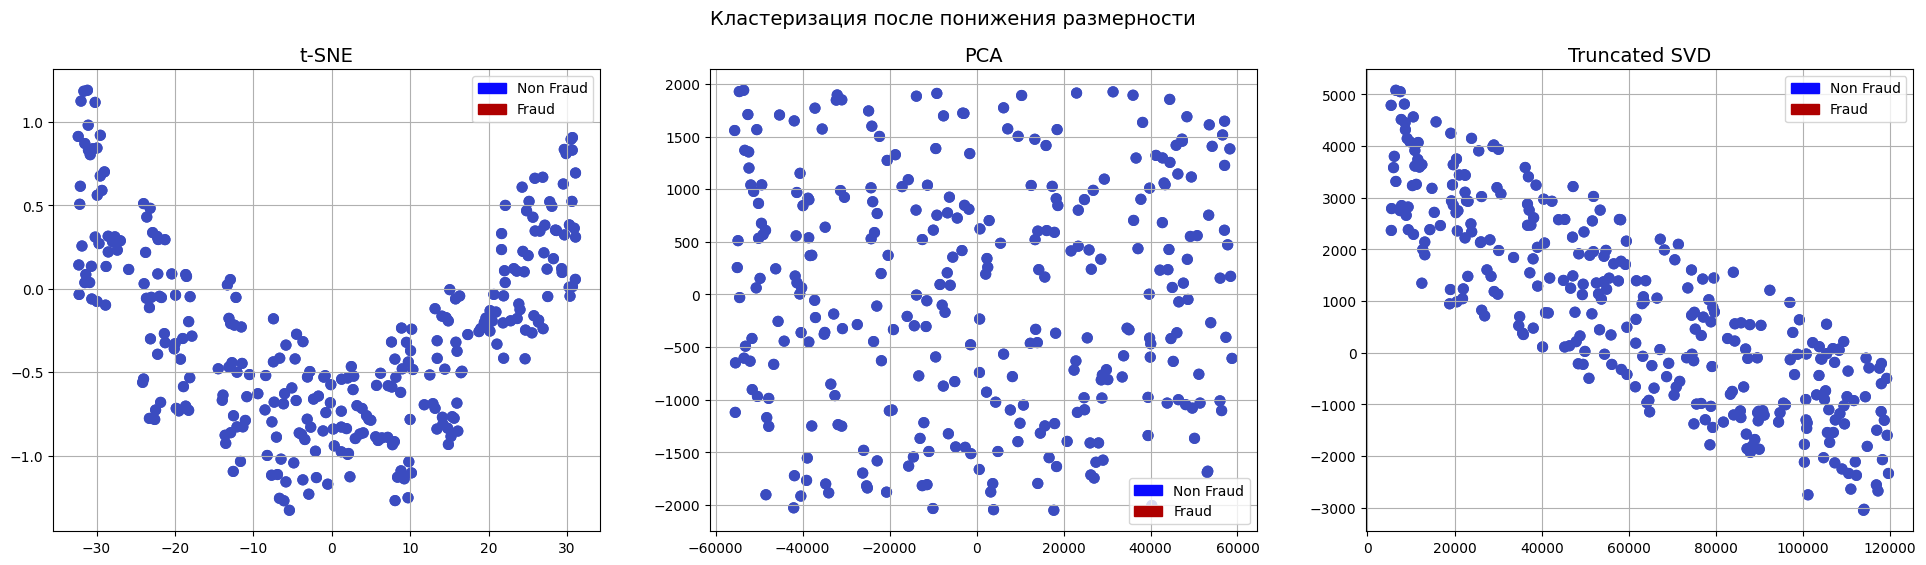

In [89]:
f, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(24,6))
f.suptitle('Кластеризация после понижения размерности', fontsize=14)


blue_patch = mpatches.Patch(color='#0A0AFF', label='Non Fraud')
red_patch = mpatches.Patch(color='#AF0000', label='Fraud')


# t-SNE scatter plot
ax1.scatter(X_reduced_tsne[:,0], X_reduced_tsne[:,1], c=(y == 0), cmap='coolwarm', label='Non Fraud', linewidths=2)
ax1.scatter(X_reduced_tsne[:,0], X_reduced_tsne[:,1], c=(y == 1), cmap='coolwarm', label='Fraud', linewidths=2)
ax1.set_title('t-SNE', fontsize=14)

ax1.grid(True)

ax1.legend(handles=[blue_patch, red_patch])


# PCA scatter plot
ax2.scatter(X_reduced_pca[:,0], X_reduced_pca[:,1], c=(y == 0), cmap='coolwarm', label='Non Fraud', linewidths=2)
ax2.scatter(X_reduced_pca[:,0], X_reduced_pca[:,1], c=(y == 1), cmap='coolwarm', label='Fraud', linewidths=2)
ax2.set_title('PCA', fontsize=14)

ax2.grid(True)

ax2.legend(handles=[blue_patch, red_patch])

# TruncatedSVD scatter plot
ax3.scatter(X_reduced_svd[:,0], X_reduced_svd[:,1], c=(y == 0), cmap='coolwarm', label='Non Fraud', linewidths=2)
ax3.scatter(X_reduced_svd[:,0], X_reduced_svd[:,1], c=(y == 1), cmap='coolwarm', label='Fraud', linewidths=2)
ax3.set_title('Truncated SVD', fontsize=14)

ax3.grid(True)

ax3.legend(handles=[blue_patch, red_patch])

plt.show()

T-SNE значительно эффективнее для визуализации и разделения классов, несмотря на медленную работу. PCA и SVD не дали хорошего разделения